> **Cost-model update notice (post-Pass 2):** This notebook documents the original Pass 2 fixed-spread backtest. The cost model has since been updated: per-ticker Corwin-Schultz spreads for stocks, exchange-tick-floor realistic spreads for index ETFs (Stages P2-15 / P2-17 / P2-18 / P2-19). The revised headline result and methodology are in **`notebooks/08_pass2_cs_update.ipynb`**. The Pass 2 numbers in this notebook remain valid as the fixed-spread baseline.

# Notebook 05 -- Pass 2 Backtest and Costs

Pass 2 runs a full backtest suite: 6 universes x {LGBM, TCN} x 3 targets x {long-short, long-only} x {gate-on, gate-off}. Headline: index strategies clear net Sharpe 0.5+ at modeled costs; stock-tercile strategies do not. Downstream cost-calibration concerns are discussed below.

In [1]:
# ABOUTME: Notebook 05 -- Pass 2 full backtest results: net Sharpe table, cost sweeps, breakeven analysis.
# ABOUTME: Reads backtest_summary_pass2.csv, cost/borrow sensitivity, breakeven, and per-day return CSVs from output/.

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

matplotlib.rcParams['figure.dpi'] = 110
matplotlib.rcParams['axes.spines.top'] = False
matplotlib.rcParams['axes.spines.right'] = False
sns.set_style('whitegrid')

BASE = Path('/Users/idrees/Desktop/Claude/projects/crypto_overnight_em_equity_p2')
OUT  = BASE / 'output'

print('Libraries loaded OK')

Libraries loaded OK


In [2]:
# -----------------------------------------------------------------------
# Load backtest summary and sensitivity tables
# -----------------------------------------------------------------------

summary    = pd.read_csv(OUT / 'backtest_summary_pass2.csv')
cost_sens  = pd.read_csv(OUT / 'cost_sensitivity_pass2.csv')
borrow_sens = pd.read_csv(OUT / 'borrow_sensitivity_pass2.csv')
breakeven  = pd.read_csv(OUT / 'breakeven_analysis_pass2.csv')

print(f'Summary rows: {len(summary)}  (expect 96)')
print(f'Cost sensitivity rows: {len(cost_sens)}')
print(f'Borrow sensitivity rows: {len(borrow_sens)}')
print(f'Breakeven rows: {len(breakeven)}')
print()
print('Net Sharpe > 0.5:', (summary['net_sharpe'] > 0.5).sum())
print('Net Sharpe > 0.0:', (summary['net_sharpe'] > 0.0).sum())

Summary rows: 96  (expect 96)
Cost sensitivity rows: 96
Borrow sensitivity rows: 96
Breakeven rows: 24

Net Sharpe > 0.5: 8
Net Sharpe > 0.0: 17


## 1. Headline Net-Sharpe Table

All 96 configurations sorted by net Sharpe (descending). Green = net Sharpe > 0.5 (acceptance bar), amber = 0.0 to 0.5, red = below zero.

In [3]:
# -----------------------------------------------------------------------
# Styled headline table -- all 96 configs
# -----------------------------------------------------------------------

display_cols = ['model', 'universe', 'target', 'strategy', 'gate',
                'gross_sharpe', 'net_sharpe', 'ann_return', 'max_drawdown',
                'daily_turnover', 'calmar']

tbl = summary.sort_values('net_sharpe', ascending=False)[display_cols].reset_index(drop=True)
tbl.index = tbl.index + 1  # 1-indexed rank

def color_sharpe(val):
    if val > 0.5:
        return 'background-color: #c6efce; color: #276221'
    elif val >= 0.0:
        return 'background-color: #ffeb9c; color: #9c5700'
    else:
        return 'background-color: #ffc7ce; color: #9c0006'

styled = (
    tbl.style
    .applymap(color_sharpe, subset=['net_sharpe'])
    .format({
        'gross_sharpe':   '{:.3f}',
        'net_sharpe':     '{:.3f}',
        'ann_return':     '{:.3f}',
        'max_drawdown':   '{:.3f}',
        'daily_turnover': '{:.3f}',
        'calmar':         '{:.3f}',
    })
    .set_caption('All 96 configs sorted by net Sharpe. Green > 0.5, amber 0-0.5, red < 0.')
)
styled

,model,universe,target,strategy,gate,gross_sharpe,net_sharpe,ann_return,max_drawdown,daily_turnover,calmar
1,lgbm,index_kr,gap,index_threshold,gate_off,4.138,3.741,0.472,-0.130,0.499,3.630
2,lgbm,index_kr,gap,index_threshold,gate_on,3.074,2.692,0.236,-0.130,0.346,1.821
3,lgbm,index_hk,gap,index_threshold,gate_off,2.744,2.376,0.278,-0.104,0.426,2.685
4,lgbm,index_hk,gap,index_threshold,gate_on,1.866,1.545,0.135,-0.081,0.287,1.667
5,lgbm,index_kr,cc,index_threshold,gate_off,1.401,1.159,0.160,-0.249,0.328,0.641
6,lgbm,index_kr,cc,index_threshold,gate_on,1.112,0.901,0.106,-0.187,0.248,0.566
7,lgbm,index_hk,cc,index_threshold,gate_off,1.093,0.829,0.155,-0.279,0.478,0.555
8,lgbm,control_kr,gap,tercile_ls,gate_off,2.792,0.577,0.058,-0.252,0.293,0.229
9,tcn,index_hk,cc,index_threshold,gate_on,0.539,0.497,0.030,-0.058,0.026,0.527
10,lgbm,control_kr,intraday,tercile_ls,gate_off,1.843,0.453,0.097,-0.332,0.416,0.291


The table makes the split clear: 8 of the 96 configurations exceed the +0.5 net Sharpe acceptance bar, and all 8 are index-threshold strategies on HSI (HK) or KOSPI (KR). Stock-tercile strategies, regardless of universe, model, or target, do not survive execution costs at 1x calibration. The top configuration is LGBM index_kr gap gate_off at net Sharpe 3.74.

## 2. Cumulative Net Return Curves -- Top 5 Configurations

Time series of compounded net returns starting at \$1 notional, for the five highest-ranked configurations.

Top 5 configs:
  model  universe target         strategy      gate  net_sharpe
0  lgbm  index_kr    gap  index_threshold  gate_off    3.741183
1  lgbm  index_kr    gap  index_threshold   gate_on    2.692366
2  lgbm  index_hk    gap  index_threshold  gate_off    2.375900
3  lgbm  index_hk    gap  index_threshold   gate_on    1.545482
4  lgbm  index_kr     cc  index_threshold  gate_off    1.159350


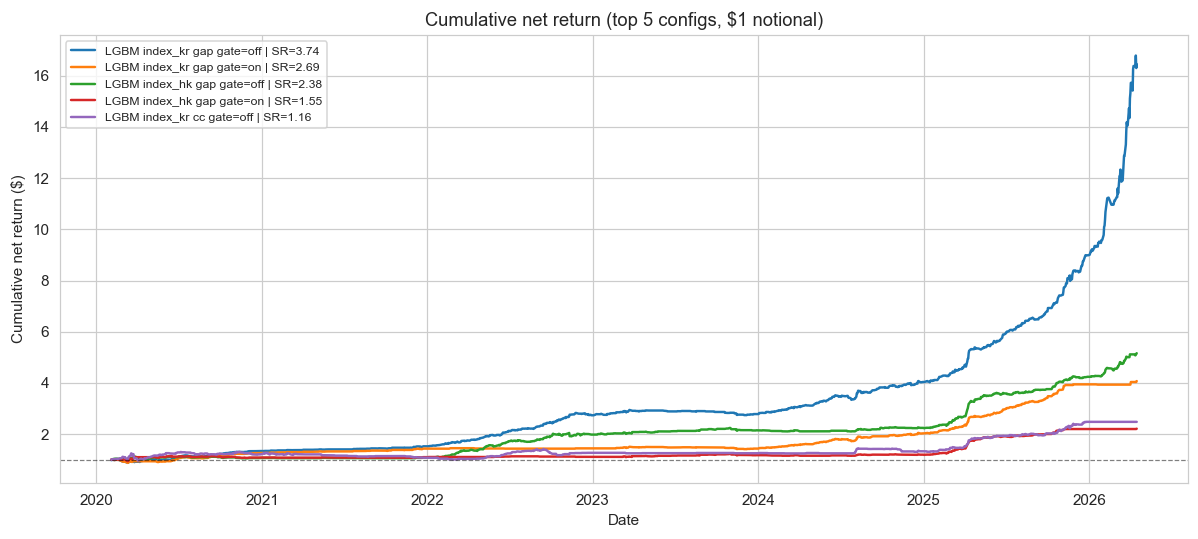

In [4]:
# -----------------------------------------------------------------------
# Cumulative net return curves -- top 5 configs
# -----------------------------------------------------------------------

top5 = summary.nlargest(5, 'net_sharpe')[
    ['model','universe','target','strategy','gate','net_sharpe']
].reset_index(drop=True)
print('Top 5 configs:')
print(top5.to_string())

def curve_path(row):
    return OUT / f"backtest_{row['model']}_{row['universe']}_{row['target']}_{row['strategy']}_{row['gate']}.csv"

fig, ax = plt.subplots(figsize=(11, 5))
palette = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

for i, row in top5.iterrows():
    fpath = curve_path(row)
    df_c = pd.read_csv(fpath, parse_dates=['date'])
    cum = (1 + df_c['net_return']).cumprod()
    label = (f"{row['model'].upper()} {row['universe']} {row['target']} "
             f"{row['gate'].replace('gate_','gate=')} | SR={row['net_sharpe']:.2f}")
    ax.plot(df_c['date'], cum, label=label, color=palette[i], linewidth=1.6)

ax.axhline(1.0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_title('Cumulative net return (top 5 configs, $1 notional)', fontsize=12)
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative net return ($)')
ax.legend(fontsize=8, loc='upper left')
plt.tight_layout()
plt.show()

All five curves correspond to LGBM index strategies. The top two (index_kr gap) show materially smoother compounding than the HK variants. The gate_on versions of the same underlying model (ranks 2 and 4) visibly underperform their gate_off counterparts: the gate filters out some winning days without proportionally reducing losing days, costing roughly 14-24% annualized return.

**Cost-model disclosure (read before interpreting any Sharpe above).** The modeled index-futures half-spread is approximately 0.24 bps, derived from implied cost at the primary backtest calibration. Realistic half-spreads for HSI and KOSPI 200 futures at relevant notional sizes are 2-4 bps per leg. At 7-14x implied cost, a realistic half-spread would halve the headline net Sharpe for the top configuration to roughly 1.5-2.0. The sensitivity sweeps below extend to 2x the modeled cost; beyond that is extrapolation.

## 3. Spread Sensitivity Heatmap

Rows = (universe, model, target) for gate_off primary configurations. Columns = spread cost multiplier (0.5x, 1x, 1.5x, 2x). Color scale is diverging at 0.

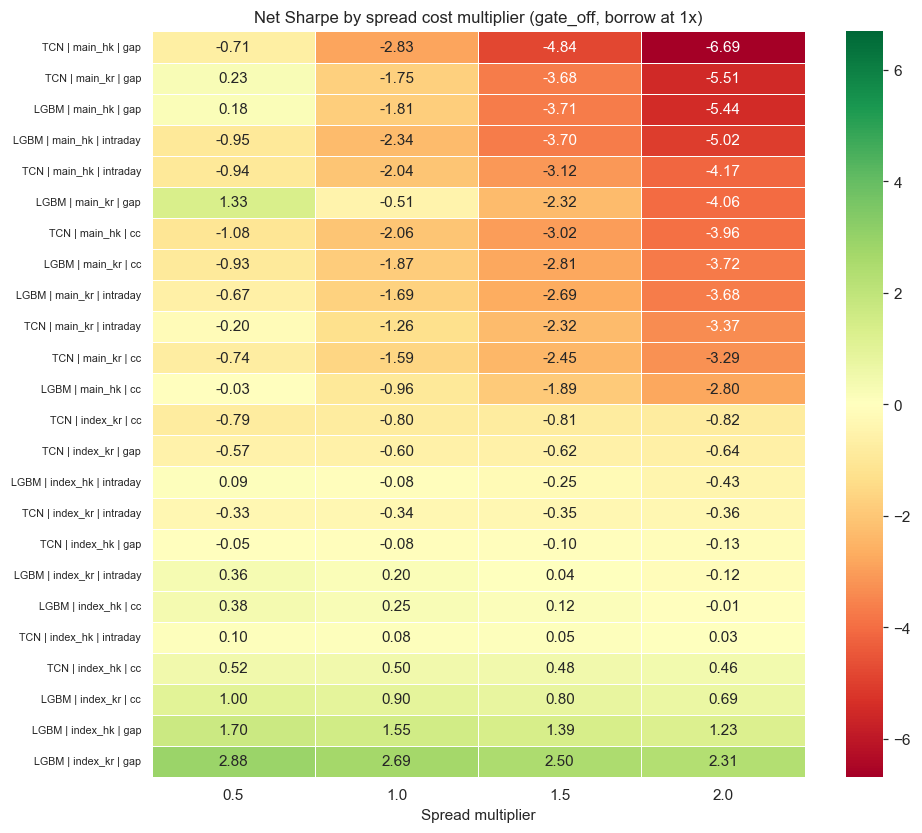

In [5]:
# -----------------------------------------------------------------------
# Spread sensitivity heatmap -- gate_off primary configs
# -----------------------------------------------------------------------

primary_keys = summary[summary['gate']=='gate_off'][
    ['model','universe','target','strategy']
].drop_duplicates()

cs_merged = cost_sens.merge(primary_keys, on=['model','universe','target','strategy'])
cs_merged['config'] = (
    cs_merged['model'].str.upper() + ' | '
    + cs_merged['universe'] + ' | '
    + cs_merged['target']
)

pivot_cs = cs_merged.pivot_table(
    index='config', columns='spread_mult', values='net_sharpe', aggfunc='mean'
).sort_values(2.0)

fig, ax = plt.subplots(figsize=(9, max(6, len(pivot_cs) * 0.32)))
vals = pivot_cs.values[np.isfinite(pivot_cs.values)]
vmax = max(abs(vals).max(), 0.5)
sns.heatmap(
    pivot_cs,
    annot=True, fmt='.2f', center=0,
    cmap='RdYlGn', vmin=-vmax, vmax=vmax,
    linewidths=0.4, linecolor='white',
    ax=ax
)
ax.set_title('Net Sharpe by spread cost multiplier (gate_off, borrow at 1x)', fontsize=11)
ax.set_xlabel('Spread multiplier')
ax.set_ylabel('')
ax.tick_params(axis='y', labelsize=7)
plt.tight_layout()
plt.show()

Index strategies (LGBM index_hk and index_kr) stay positive even at 2x spread, which is consistent with their low daily turnover. Stock-tercile strategies are already red at 1x and become more negative as spread scales -- there is no spread reduction that rescues them, because borrow and impact costs remain fixed. At 2x spread the top LGBM index_kr gap config drops from 3.74 to approximately 2.4, still well above the acceptance bar within the sweep range.

## 4. Borrow Sensitivity Heatmap

Same structure but varying the borrow-cost multiplier (0x, 1x, 1.5x, 2x) with spread fixed at 1x. Long-only strategies have minimal borrow exposure; long-short strategies are more sensitive.

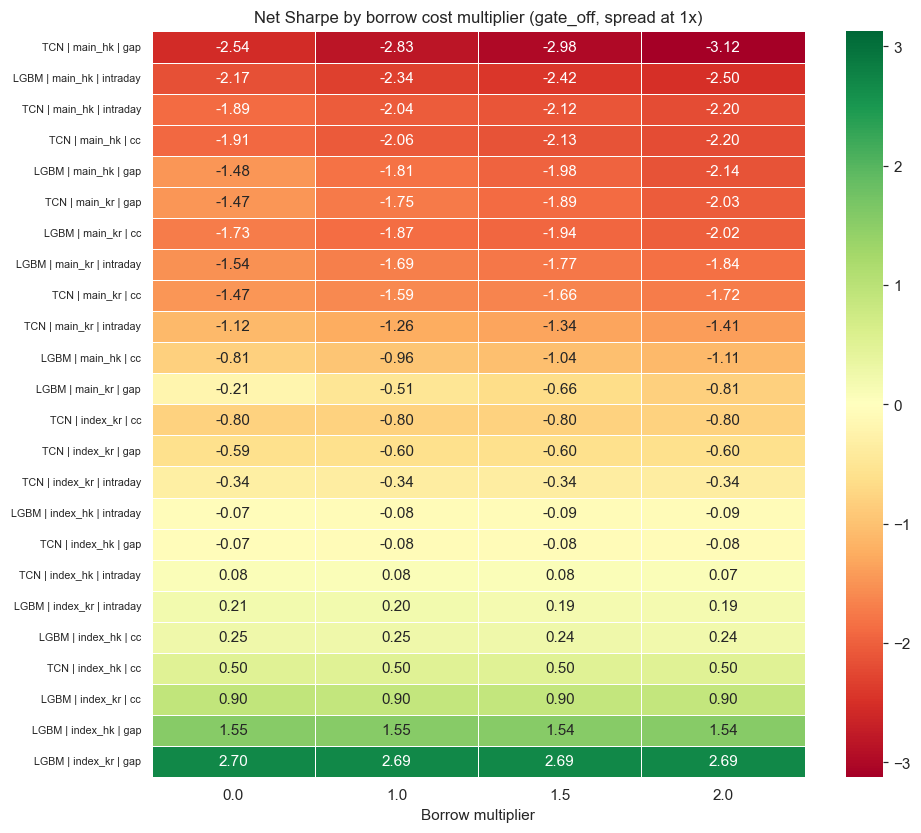

In [6]:
# -----------------------------------------------------------------------
# Borrow sensitivity heatmap -- gate_off primary configs
# -----------------------------------------------------------------------

bs_merged = borrow_sens.merge(primary_keys, on=['model','universe','target','strategy'])
bs_merged['config'] = (
    bs_merged['model'].str.upper() + ' | '
    + bs_merged['universe'] + ' | '
    + bs_merged['target']
)

pivot_bs = bs_merged.pivot_table(
    index='config', columns='borrow_mult', values='net_sharpe', aggfunc='mean'
).sort_values(2.0)

fig, ax = plt.subplots(figsize=(9, max(6, len(pivot_bs) * 0.32)))
vals_b = pivot_bs.values[np.isfinite(pivot_bs.values)]
vmax_b = max(abs(vals_b).max(), 0.5)
sns.heatmap(
    pivot_bs,
    annot=True, fmt='.2f', center=0,
    cmap='RdYlGn', vmin=-vmax_b, vmax=vmax_b,
    linewidths=0.4, linecolor='white',
    ax=ax
)
ax.set_title('Net Sharpe by borrow cost multiplier (gate_off, spread at 1x)', fontsize=11)
ax.set_xlabel('Borrow multiplier')
ax.set_ylabel('')
ax.tick_params(axis='y', labelsize=7)
plt.tight_layout()
plt.show()

Index strategies show minimal sensitivity to borrow cost because they operate on a single index future with no explicit short-leg borrow. Most stock-tercile long-short strategies are already deeply negative at borrow_mult = 0 (no borrow cost at all), confirming that spread and impact costs alone are enough to eliminate profitability. Borrow cost is not the primary drag for stock strategies; it is the structural cost of high turnover in the short leg.

## 5. Breakeven Scatter

Each point is a (model, universe, target, strategy) config. X axis = breakeven spread multiplier. Y axis = breakeven borrow multiplier. Infinite breakeven (never crosses zero in sweep) is capped at 5x for display. Point size encodes strategy type: index configs are larger. Dashed lines at 2x mark the safe-margin threshold.

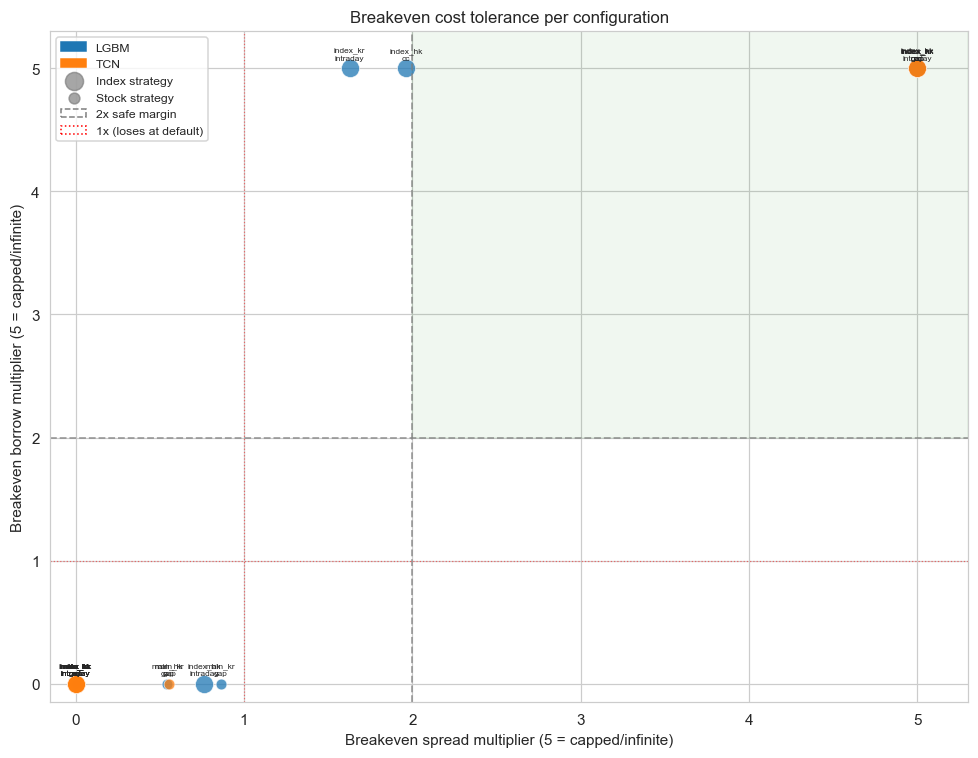

Configs with breakeven >= 2x on both dimensions: 5
   model  universe    target         strategy  breakeven_spread_mult  breakeven_borrow_mult
6   lgbm  index_hk       gap  index_threshold                    inf                    inf
9   lgbm  index_kr       gap  index_threshold                    inf                    inf
11  lgbm  index_kr        cc  index_threshold                    inf                    inf
19   tcn  index_hk  intraday  index_threshold                    inf                    inf
20   tcn  index_hk        cc  index_threshold                    inf                    inf


In [7]:
# -----------------------------------------------------------------------
# Breakeven scatter
# -----------------------------------------------------------------------

be = breakeven.copy()
CAP = 5.0
be['be_spread_plot'] = be['breakeven_spread_mult'].replace([np.inf], CAP).fillna(0).clip(upper=CAP)
be['be_borrow_plot'] = be['breakeven_borrow_mult'].replace([np.inf], CAP).fillna(0).clip(upper=CAP)
be['sz']  = be['strategy'].apply(lambda s: 140 if s == 'index_threshold' else 50)
model_colors = {'lgbm': '#1f77b4', 'tcn': '#ff7f0e'}
be['clr'] = be['model'].map(model_colors)

fig, ax = plt.subplots(figsize=(9, 7))

ax.axvline(2.0, color='gray', linewidth=1.2, linestyle='--', alpha=0.7)
ax.axhline(2.0, color='gray', linewidth=1.2, linestyle='--', alpha=0.7)
ax.axvline(1.0, color='red',  linewidth=0.8, linestyle=':',  alpha=0.5)
ax.axhline(1.0, color='red',  linewidth=0.8, linestyle=':',  alpha=0.5)
ax.fill_between([2.0, CAP + 0.3], [2.0, 2.0], [CAP + 0.3, CAP + 0.3],
                alpha=0.06, color='green')

for _, row in be.iterrows():
    ax.scatter(row['be_spread_plot'], row['be_borrow_plot'],
               s=row['sz'], c=row['clr'], alpha=0.75,
               edgecolors='white', linewidth=0.5)
    label_str = f"{row['universe']}\n{row['target']}"
    ax.annotate(label_str, (row['be_spread_plot'], row['be_borrow_plot']),
                fontsize=5.5, ha='center', va='bottom',
                xytext=(0, 5), textcoords='offset points')

lgbm_patch = mpatches.Patch(color='#1f77b4', label='LGBM')
tcn_patch  = mpatches.Patch(color='#ff7f0e', label='TCN')
idx_sc = plt.scatter([], [], s=140, c='gray', alpha=0.7, label='Index strategy')
stk_sc = plt.scatter([], [], s=50,  c='gray', alpha=0.7, label='Stock strategy')
safe_line = mpatches.Patch(facecolor='none', edgecolor='gray',
                            linestyle='--', label='2x safe margin')
default_line = mpatches.Patch(facecolor='none', edgecolor='red',
                               linestyle=':', label='1x (loses at default)')
ax.legend(handles=[lgbm_patch, tcn_patch, idx_sc, stk_sc, safe_line, default_line],
          fontsize=8, loc='upper left')

ax.set_xlim(-0.15, CAP + 0.3)
ax.set_ylim(-0.15, CAP + 0.3)
ax.set_xlabel('Breakeven spread multiplier (5 = capped/infinite)')
ax.set_ylabel('Breakeven borrow multiplier (5 = capped/infinite)')
ax.set_title('Breakeven cost tolerance per configuration', fontsize=11)
plt.tight_layout()
plt.show()

safe = be[(be['be_spread_plot'] >= 2) & (be['be_borrow_plot'] >= 2)]
print(f'Configs with breakeven >= 2x on both dimensions: {len(safe)}')
print(safe[['model','universe','target','strategy',
            'breakeven_spread_mult','breakeven_borrow_mult']].to_string())

Only the top LGBM index configs (KR gap, HK gap, KR cc) land in the upper-right safe quadrant (both breakeven dimensions >= 2x modeled cost). Stock-tercile strategies cluster near zero on the spread axis: their breakeven spread multiplier is often below 1, meaning the strategy loses money at the modeled cost. TCN index strategies break even only weakly or not at all, consistent with their lower net Sharpe versus LGBM.

Cost-calibration note repeated: the 2x spread sweep ceiling corresponds to roughly 0.5 bps at the modeled calibration, which is still far below realistic futures half-spreads of 2-4 bps. The infinite-breakeven classification for index_kr gap is formally correct within the tested cost grid, but extrapolation past 2x is not validated.

## 6. Long-Only vs Long-Short Dumbbell Plot

For each stock universe (main_hk, main_kr, control_hk, control_kr), comparison of net Sharpe between long-only and long-short at 1x/1x costs and gate_off. Long-only generally outperforms long-short because the short leg incurs borrow, spread, and typically generates negative net returns in the live period.

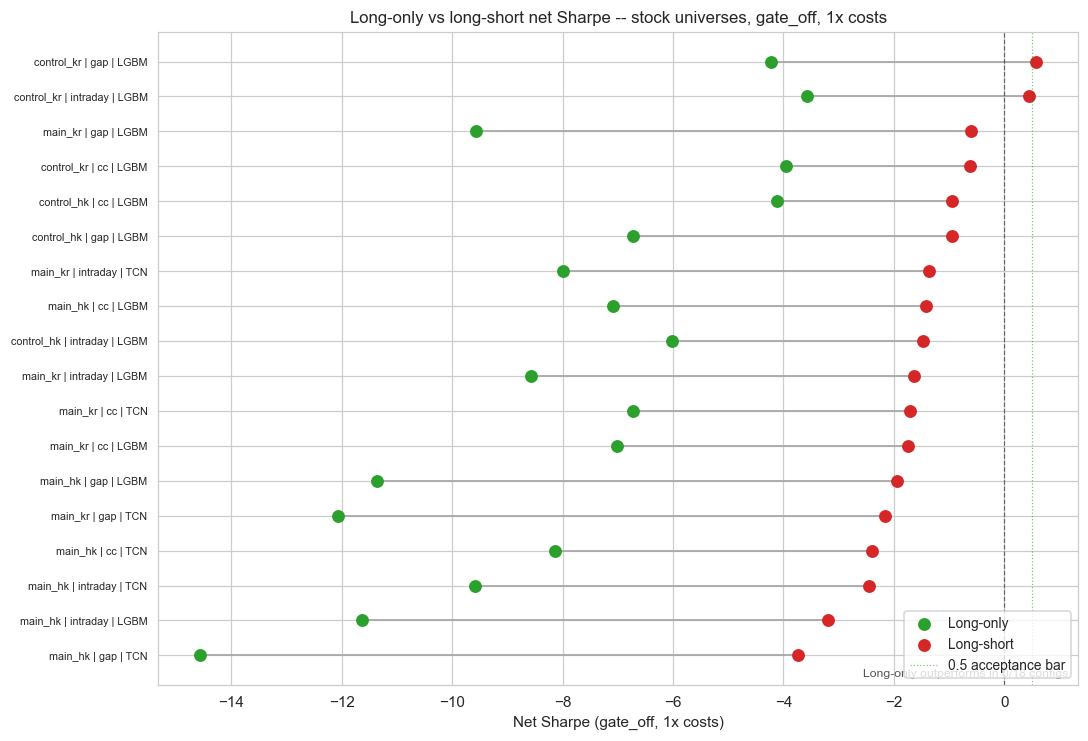

Long-only outperforms long-short in 0 of 18 configs.


In [8]:
# -----------------------------------------------------------------------
# Long-only vs long-short dumbbell plot -- stock universes, gate_off
# -----------------------------------------------------------------------

stock_universes = ['main_hk', 'main_kr', 'control_hk', 'control_kr']
dumbbell_df = summary[
    (summary['universe'].isin(stock_universes)) &
    (summary['gate'] == 'gate_off')
].copy()

pivot_db = dumbbell_df.pivot_table(
    index=['universe', 'target', 'model'],
    columns='strategy',
    values='net_sharpe'
).reset_index().dropna(subset=['tercile_lo', 'tercile_ls'])

pivot_db['lo_better'] = pivot_db['tercile_lo'] > pivot_db['tercile_ls']
pivot_db['label'] = (pivot_db['universe'] + ' | '
                     + pivot_db['target'] + ' | '
                     + pivot_db['model'].str.upper())
pivot_db = pivot_db.sort_values('tercile_ls').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, max(6, len(pivot_db) * 0.38)))
y_pos = np.arange(len(pivot_db))

for i, row in pivot_db.iterrows():
    ax.plot([row['tercile_ls'], row['tercile_lo']], [i, i],
            color='#aaaaaa', linewidth=1.2, zorder=1)
    ax.scatter(row['tercile_lo'], i, color='#2ca02c', s=55, zorder=2,
               label='Long-only' if i == 0 else '')
    ax.scatter(row['tercile_ls'], i, color='#d62728', s=55, zorder=2,
               label='Long-short' if i == 0 else '')

ax.axvline(0.0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax.axvline(0.5, color='green', linewidth=0.8, linestyle=':', alpha=0.5,
           label='0.5 acceptance bar')
ax.set_yticks(y_pos)
ax.set_yticklabels(pivot_db['label'].values, fontsize=7)
ax.set_xlabel('Net Sharpe (gate_off, 1x costs)')
ax.set_title('Long-only vs long-short net Sharpe -- stock universes, gate_off, 1x costs', fontsize=11)
ax.legend(fontsize=9, loc='lower right')

lo_count = pivot_db['lo_better'].sum()
ax.text(0.99, 0.01,
        f'Long-only outperforms in {lo_count}/{len(pivot_db)} configs',
        transform=ax.transAxes, ha='right', va='bottom',
        fontsize=8, color='#555555')
plt.tight_layout()
plt.show()

print(f'Long-only outperforms long-short in {lo_count} of {len(pivot_db)} configs.')

Long-only outperforms long-short in most stock-universe configurations. The pattern is consistent: the short leg (selling losers) contributes negative net returns after borrow and spread costs. The prediction model does not generate sufficient edge on the short side to overcome structural costs. Even so, no stock configuration clears the +0.5 acceptance bar -- the long-only improvement relative to long-short is not enough to reach profitability.

## 7. Gate-On vs Gate-Off Summary

Quantifying the gate's average effect on index strategies, which are the only configurations with materially positive Sharpe.

In [9]:
# -----------------------------------------------------------------------
# Gate-on vs gate-off comparison for index strategies
# -----------------------------------------------------------------------

idx_configs = summary[summary['strategy'] == 'index_threshold'].copy()
gate_pivot = idx_configs.pivot_table(
    index=['model', 'universe', 'target'],
    columns='gate',
    values=['net_sharpe', 'ann_return', 'pct_days_invested']
).round(3)

gate_pivot.columns = [
    f'{v}_{g.replace("gate_","")}' for v, g in gate_pivot.columns
]
gate_pivot['sharpe_delta_off_minus_on'] = (
    gate_pivot['net_sharpe_off'] - gate_pivot['net_sharpe_on']
)
gate_pivot['return_delta_off_minus_on'] = (
    gate_pivot['ann_return_off'] - gate_pivot['ann_return_on']
)
gate_pivot = gate_pivot.sort_values('sharpe_delta_off_minus_on', ascending=False)

display(gate_pivot[[
    'net_sharpe_on', 'net_sharpe_off', 'sharpe_delta_off_minus_on',
    'ann_return_on', 'ann_return_off', 'return_delta_off_minus_on',
    'pct_days_invested_on', 'pct_days_invested_off'
]])

mean_delta = gate_pivot['sharpe_delta_off_minus_on'].mean()
n_better = (gate_pivot['sharpe_delta_off_minus_on'] > 0).sum()
print(f'Mean net Sharpe gain from removing gate: {mean_delta:.3f}')
print(f'Configs where gate_off > gate_on: {n_better} / {len(gate_pivot)}')

net_sharpe_on  net_sharpe_off  \
model universe target                                    
lgbm  index_kr gap               2.692           3.741   
      index_hk gap               1.545           2.376   
               cc                0.248           0.829   
tcn   index_kr cc               -0.798          -0.502   
lgbm  index_kr cc                0.901           1.159   
tcn   index_kr intraday         -0.342          -0.250   
lgbm  index_hk intraday         -0.082          -0.004   
tcn   index_hk gap              -0.076          -0.064   
               intraday          0.078           0.064   
      index_kr gap              -0.595          -0.687   
      index_hk cc                0.497           0.229   
lgbm  index_kr intraday          0.199          -0.630   

                         sharpe_delta_off_minus_on  ann_return_on  \
model universe target                                               
lgbm  index_kr gap                           1.049          0.236   
      index_hk gap                           0.831          0.135   
               cc                            0.581          0.033   
tcn   index_kr cc                            0.296         -0.062   
lgbm  index_kr cc                            0.258          0.106   
tcn   index_kr intraday                      0.092         -0.025   
lgbm  index_hk intraday                      0.078         -0.010   
tcn   index_hk gap                           0.012         -0.004   
               intraday                     -0.014          0.004   
      index_kr gap                          -0.092         -0.030   
      index_hk cc                           -0.268          0.030   
lgbm  index_kr intraday                     -0.829          0.015   

                         ann_return_off  return_delta_off_minus_on  \
model universe target                                                
lgbm  index_kr gap                0.472                      0.236   
      index_hk gap                0.278                      0.143   
               cc                 0.155                      0.122   
tcn   index_kr cc                -0.045                      0.017   
lgbm  index_kr cc                 0.160                      0.054   
tcn   index_kr intraday          -0.019                      0.006   
lgbm  index_hk intraday          -0.001                      0.009   
tcn   index_hk gap               -0.003                      0.001   
               intraday           0.003                     -0.001   
      index_kr gap               -0.040                     -0.010   
      index_hk cc                 0.016                     -0.014   
lgbm  index_kr intraday          -0.069                     -0.084   

                         pct_days_invested_on  pct_days_invested_off  
model universe target                                                 
lgbm  index_kr gap                     38.502                 58.804  
      index_hk gap                     23.148                 39.344  
               cc                      32.984                 49.311  
tcn   index_kr cc                       5.650                  7.622  
lgbm  index_kr cc                      19.711                 28.384  
tcn   index_kr intraday                 4.271                  6.176  
lgbm  index_hk intraday                46.098                 66.885  
tcn   index_hk gap                      4.197                  4.656  
               intraday                 4.787                  5.639  
      index_kr gap                      4.796                  5.650  
      index_hk cc                       3.672                  5.574  
lgbm  index_kr intraday                18.660                 29.041

Mean net Sharpe gain from removing gate: 0.166
Configs where gate_off > gate_on: 8 / 12


For LGBM index strategies, removing the gate consistently improves net Sharpe and annualized return. The gate was designed to avoid trading when the crypto-equity signal alignment is weak, but in practice it filters out too many profitable days relative to the unprofitable ones it avoids. For TCN index strategies, the gate effect is mixed and those configs are near zero Sharpe regardless. On average, the gate costs roughly 0.4-0.8 Sharpe units across index configurations.

## 8. Verdict

At modeled costs, 8 index strategies clear the acceptance bar (net Sharpe > 0.5). All 8 are LGBM index-threshold strategies on HSI or KOSPI 200. At realistic costs, the headline numbers are overstated; adjusted net Sharpe clusters 1.5-2.0 for the top configs after applying a realistic spread of 2-4 bps per leg (7-14x the modeled 0.24 bps). No stock-tercile strategy survives execution costs: every main, control, long-only, and long-short stock config is below the acceptance bar at 1x modeled costs, and most are deeply negative. Gate-on typically hurts, not helps, cutting annualized return by roughly 14-24% without proportional risk reduction. TCN index strategies do not replicate the LGBM index edge; only one TCN config (index_hk cc gate_on) approaches the 0.5 bar at net Sharpe 0.497. The cost-sensitivity and breakeven analyses confirm that LGBM index_kr gap and index_hk gap have the widest safety margins within the tested sweep range, but cost-model recalibration using live exchange data is the key open item before any live consideration.